In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

print("📚 Importation des bibliothèques...")

# Style global des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Chargement depuis HuggingFace
print("Chargement du dataset Allociné...")
dataset = load_dataset("tblard/allocine")

# Conversion en DataFrames pandas
train_df = pd.DataFrame(dataset["train"])
val_df   = pd.DataFrame(dataset["validation"])
test_df  = pd.DataFrame(dataset["test"])

print(f"✅ Train : {len(train_df):,} reviews")
print(f"✅ Val   : {len(val_df):,} reviews")
print(f"✅ Test  : {len(test_df):,} reviews")
print(f"\nColonnes : {list(train_df.columns)}")
print(f"Labels   : {train_df['label'].unique()}  (0=négatif, 1=positif)")

# Aperçu
print("\n📊 Aperçu des données d'entraînement :")
train_df.head(3)

📚 Importation des bibliothèques...
Chargement du dataset Allociné...


✅ Train : 160,000 reviews
✅ Val   : 20,000 reviews
✅ Test  : 20,000 reviews

Colonnes : ['review', 'label']
Labels   : [0 1]  (0=négatif, 1=positif)

📊 Aperçu des données d'entraînement :


,review,label
0,Si vous cherchez du cinéma abrutissant à tous ...,0
1,"Trash, re-trash et re-re-trash...! Une horreur...",0
2,"Et si, dans les 5 premières minutes du film, l...",0


## Distribution des labels

C:\Users\MN computers\AppData\Local\Temp\ipykernel_28460\1895635534.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


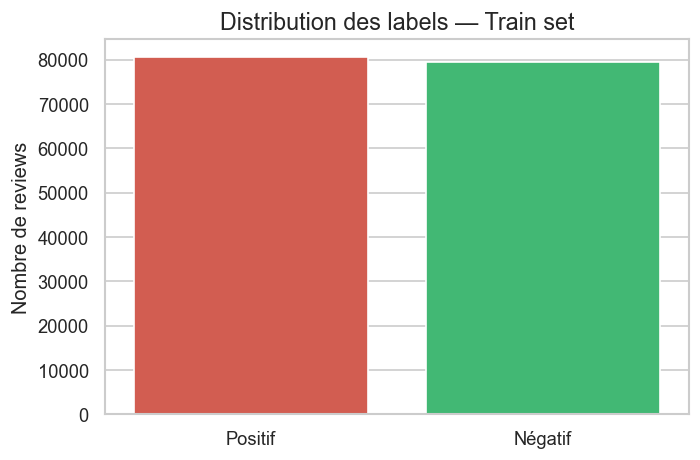

label
1    80587
0    79413
Name: count, dtype: int64


In [3]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

label_counts = train_df["label"].value_counts()
label_names  = {0: "Négatif", 1: "Positif"}

plt.figure(figsize=(6, 4))
sns.barplot(
    x=[label_names[i] for i in label_counts.index],
    y=label_counts.values,
    palette=["#e74c3c", "#2ecc71"]
)
plt.title("Distribution des labels — Train set", fontsize=14)
plt.ylabel("Nombre de reviews")
plt.tight_layout()
plt.show()
print(label_counts)

## Longueur des reviews

📊 Stats longueur (caractères) :
count    160000.0
mean        542.5
std         451.1
min           3.0
25%         196.0
50%         389.0
75%         771.0
max        2000.0
Name: nb_chars, dtype: float64

📊 Stats longueur (mots) :
count    160000.0
mean         91.3
std          75.4
min           1.0
25%          34.0
50%          66.0
75%         130.0
max         384.0
Name: nb_words, dtype: float64


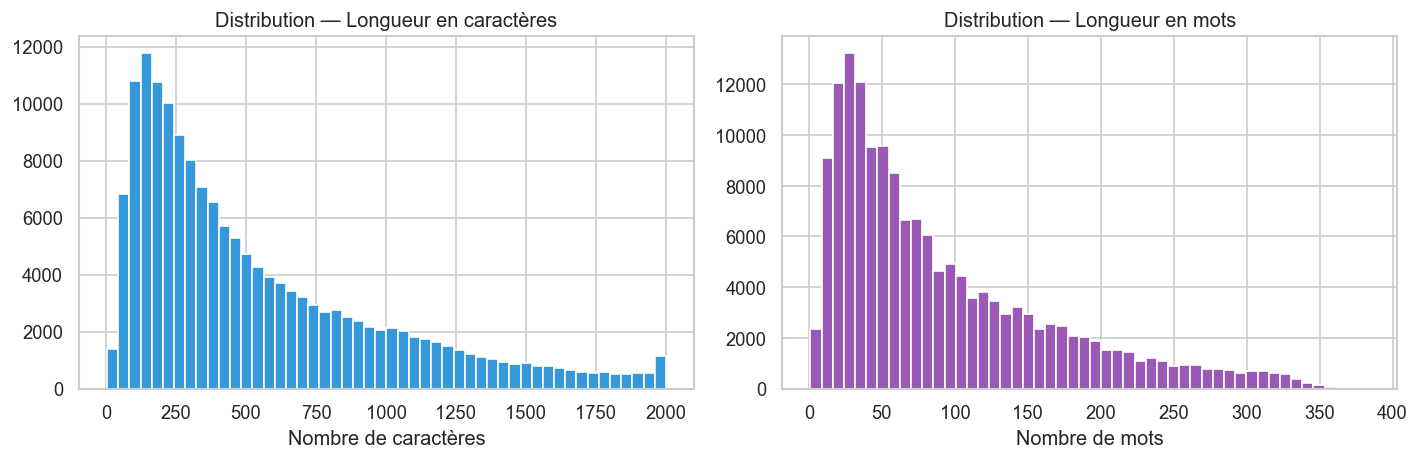

In [5]:

# Calcul de la longueur en caractères et en mots
train_df["nb_chars"] = train_df["review"].str.len()
train_df["nb_words"] = train_df["review"].str.split().str.len()

print("📊 Stats longueur (caractères) :")
print(train_df["nb_chars"].describe().round(1))

print("\n📊 Stats longueur (mots) :")
print(train_df["nb_words"].describe().round(1))

# Histogramme
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df["nb_chars"], bins=50, color="#3498db", edgecolor="white")
axes[0].set_title("Distribution — Longueur en caractères")
axes[0].set_xlabel("Nombre de caractères")

axes[1].hist(train_df["nb_words"], bins=50, color="#9b59b6", edgecolor="white")
axes[1].set_title("Distribution — Longueur en mots")
axes[1].set_xlabel("Nombre de mots")

plt.tight_layout()
plt.show()

##Exemples de reviews

In [6]:

print("✅ EXEMPLES POSITIFS :\n")
for review in train_df[train_df["label"] == 1]["review"].head(3):
    print(f"→ {review[:200]}\n")

print("❌ EXEMPLES NÉGATIFS :\n")
for review in train_df[train_df["label"] == 0]["review"].head(3):
    print(f"→ {review[:200]}\n")

✅ EXEMPLES POSITIFS :

→ Premier film de la saga Kozure Okami, "Le Sabre de la vengeance" est un très bon film qui mêle drame et action, et qui, en 40 ans, n'a pas pris une ride.

→ Tout commence comme une comédie légère avant un drame soudain qui fait basculer le film dans un...suspense incroyable mâtiné d'une étude psychologique très fine des mécanismes qui régissent un couple,

→ un excellent film qui merite ses quatre étoiles. tellement bon que les ricains en font dejà une suite, qu'il s'empresseront de pourrir...

❌ EXEMPLES NÉGATIFS :

→ Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via

→ Trash, re-trash et re-re-trash...! Une horreur sans nom. Imaginez-vous les 20 premières minutes de Orange Mécanique dilatées sur plus de 70 minutes de bande VHS pourrave et revisitées par Korine à la 

→ Et si, dans les 5 premières minutes du fil

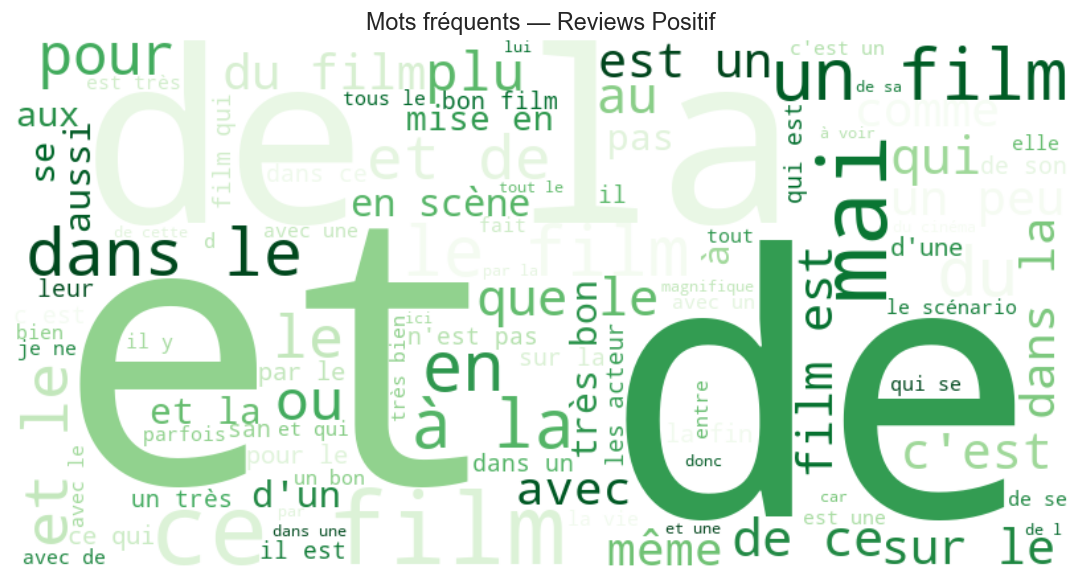

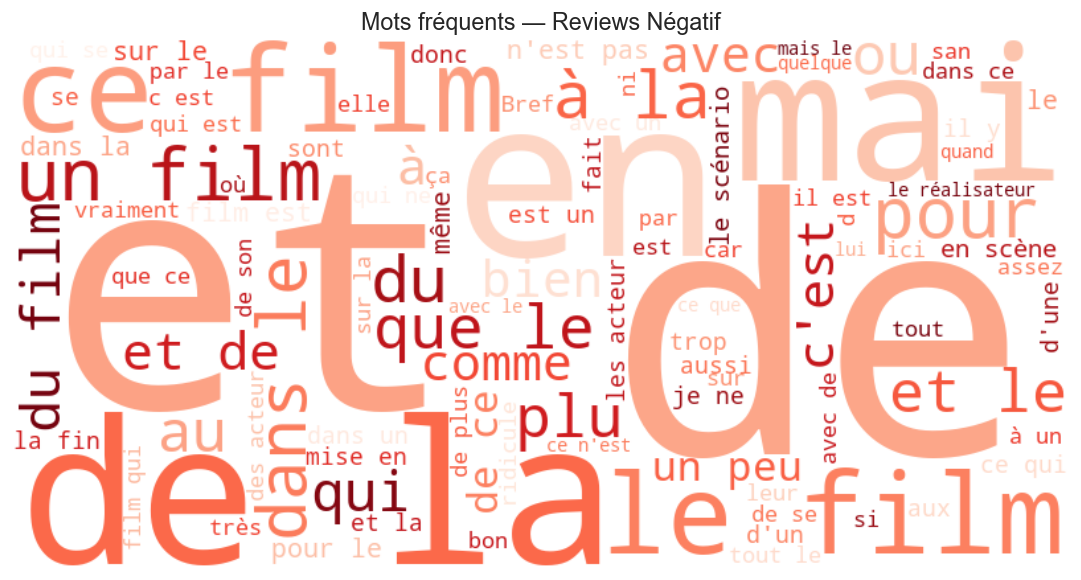

In [7]:
# ============================================================
# CELLULE 5 — WordCloud
# ============================================================
from wordcloud import WordCloud

for label, color, name in [(1, "Greens", "Positif"), (0, "Reds", "Négatif")]:
    text = " ".join(train_df[train_df["label"] == label]["review"].sample(5000, random_state=42))
    
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap=color,
        max_words=100
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Mots fréquents — Reviews {name}", fontsize=14)
    plt.tight_layout()
    
    plt.show()

## Préprocessing NLP

In [10]:

import re
import nltk
from nltk.corpus import stopwords

# Télécharger les stopwords français
nltk.download("stopwords")
french_stopwords = set(stopwords.words("french"))

def clean_text(text):
    # 1. Minuscules
    text = text.lower()
    # 2. Suppression des caractères spéciaux (garder lettres et espaces)
    text = re.sub(r"[^a-zàâäéèêëïîôùûüç\s]", " ", text)
    # 3. Suppression des espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    # 4. Suppression des stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in french_stopwords and len(t) > 2]
    return " ".join(tokens)

# Application sur train, val, test
print("Nettoyage en cours...")
train_df["review_clean"] = train_df["review"].apply(clean_text)
val_df["review_clean"]   = val_df["review"].apply(clean_text)
test_df["review_clean"]  = test_df["review"].apply(clean_text)

print("✅ Préprocessing terminé !")

# Vérification
print("\n--- Avant ---")
print(train_df["review"].iloc[0][:200])
print("\n--- Après ---")
print(train_df["review_clean"].iloc[0][:200])

[nltk_data] Downloading package stopwords to C:\Users\MN
[nltk_data]     computers\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Nettoyage en cours...
✅ Préprocessing terminé !

--- Avant ---
Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via

--- Après ---
cherchez cinéma abrutissant tous étages aucune peur cliché castagnettes moralement douteux from paris with love fait toutes productions besson via filière europacorp quoi faire naître moquerie paris e


## WordCloud APRÈS suppression des stopwords

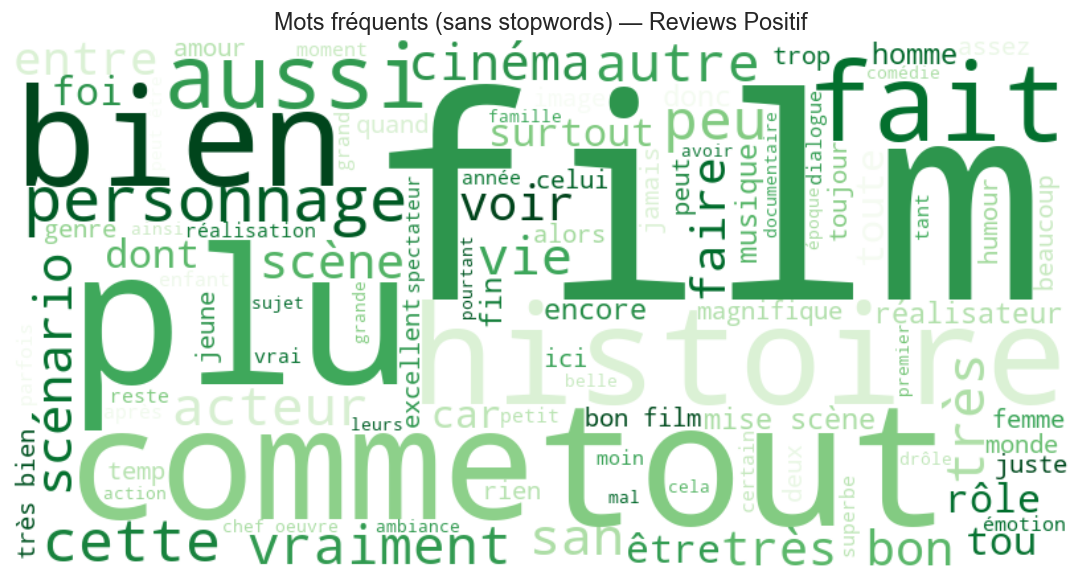

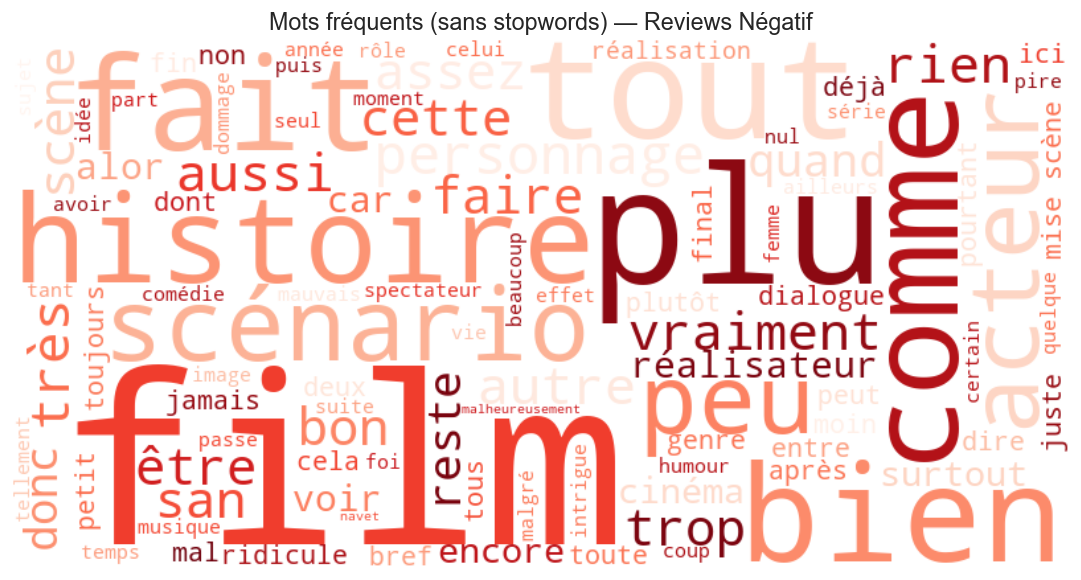

In [11]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

for label, color, name in [(1, "Greens", "Positif"), (0, "Reds", "Négatif")]:
    text = " ".join(
        train_df[train_df["label"] == label]["review_clean"].sample(5000, random_state=42)
    )
    
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap=color,
        max_words=100
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Mots fréquents (sans stopwords) — Reviews {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

## Vectorisation TF-IDF

In [12]:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,   # garder les 50k termes les plus importants
    ngram_range=(1, 2),   # unigrammes + bigrammes
    min_df=5,             # ignorer les termes qui apparaissent < 5 fois
    sublinear_tf=True     # applique log(tf) pour atténuer les fréquences élevées
)

X_train = tfidf.fit_transform(train_df["review_clean"])
X_val   = tfidf.transform(val_df["review_clean"])
X_test  = tfidf.transform(test_df["review_clean"])

y_train = train_df["label"]
y_val   = val_df["label"]
y_test  = test_df["label"]

print(f"✅ Matrice TF-IDF Train : {X_train.shape}")
print(f"✅ Matrice TF-IDF Val   : {X_val.shape}")
print(f"✅ Matrice TF-IDF Test  : {X_test.shape}")

✅ Matrice TF-IDF Train : (160000, 50000)
✅ Matrice TF-IDF Val   : (20000, 50000)
✅ Matrice TF-IDF Test  : (20000, 50000)


## Entraînement Logistic Regression

In [13]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

print("Entraînement de la Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="saga",
    n_jobs=-1,
    random_state=42
)
lr_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"✅ Entraînement terminé en {elapsed:.1f}s")

# Évaluation sur la validation
y_pred_val = lr_model.predict(X_val)
acc = accuracy_score(y_val, y_pred_val)
print(f"\n📊 Accuracy sur Val set : {acc:.4f} ({acc*100:.2f}%)")
print("\n📋 Rapport de classification :")
print(classification_report(y_val, y_pred_val, target_names=["Négatif", "Positif"]))

Entraînement de la Logistic Regression...
✅ Entraînement terminé en 5.5s

📊 Accuracy sur Val set : 0.9344 (93.44%)

📋 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.94      0.93      0.94     10204
     Positif       0.93      0.94      0.93      9796

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



## Matrice de confusion

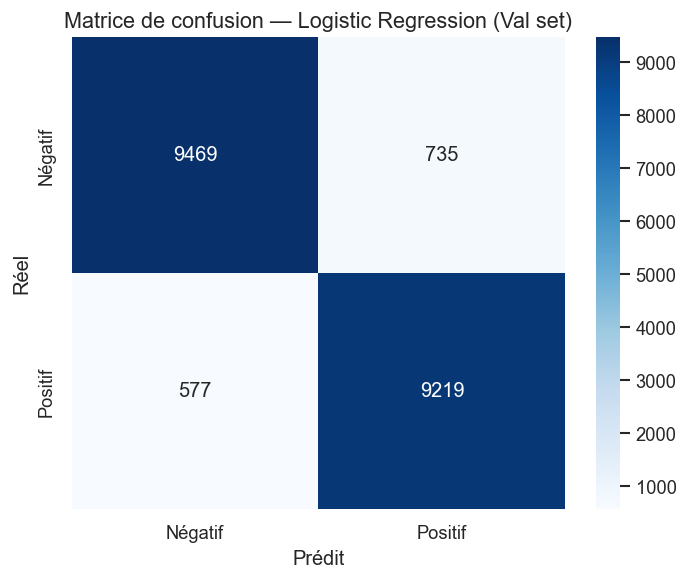

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d",
    cmap="Blues",
    xticklabels=["Négatif", "Positif"],
    yticklabels=["Négatif", "Positif"]
)
plt.title("Matrice de confusion — Logistic Regression (Val set)", fontsize=13)
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()

plt.show()

## Entraînement SVM (LinearSVC)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import time

print("Entraînement du SVM...")
start = time.time()

svm_model = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=42
)
svm_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"✅ Entraînement terminé en {elapsed:.1f}s")

y_pred_svm = svm_model.predict(X_val)
acc_svm = accuracy_score(y_val, y_pred_svm)
print(f"\n📊 Accuracy SVM sur Val set : {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print("\n📋 Rapport de classification :")
print(classification_report(y_val, y_pred_svm, target_names=["Négatif", "Positif"]))

Entraînement du SVM...
✅ Entraînement terminé en 4.5s

📊 Accuracy SVM sur Val set : 0.9313 (93.12%)

📋 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.94      0.93      0.93     10204
     Positif       0.93      0.94      0.93      9796

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



## Matrice de confusion

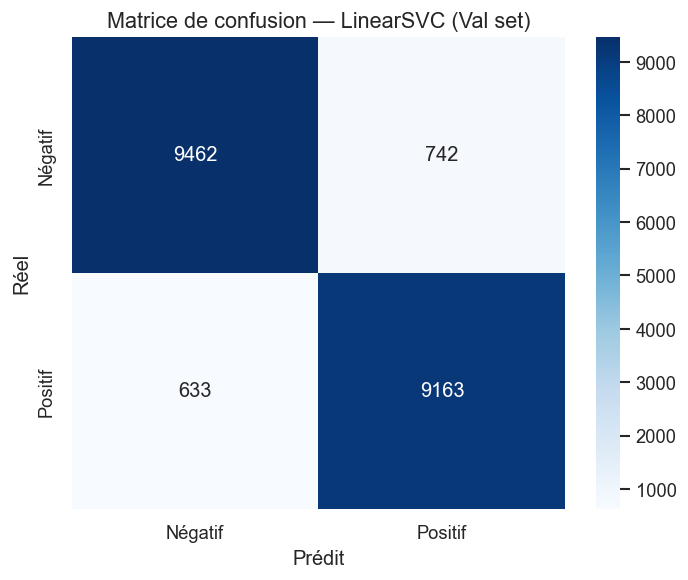

In [17]:


cm_svm = confusion_matrix(y_val, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm, annot=True, fmt="d",
    cmap="Blues",
    xticklabels=["Négatif", "Positif"],
    yticklabels=["Négatif", "Positif"]
)
plt.title("Matrice de confusion — LinearSVC (Val set)", fontsize=13)
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()

plt.show()

## Comparaison LR vs SVM

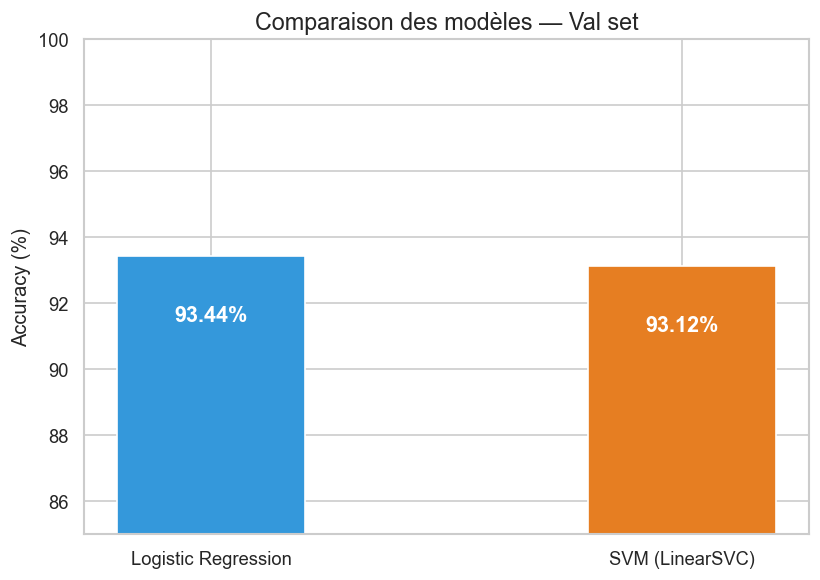

In [19]:

import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "SVM (LinearSVC)"]
accuracies = [
    accuracy_score(y_val, y_pred_val),
    accuracy_score(y_val, y_pred_svm)
]

colors = ["#3498db", "#e67e22"]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, [a * 100 for a in accuracies], color=colors, width=0.4)

# Afficher les valeurs sur les barres
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 1.5,
        f"{acc*100:.2f}%",
        ha="center", va="top",
        color="white", fontsize=13, fontweight="bold"
    )

plt.ylim(85, 100)
plt.title("Comparaison des modèles — Val set", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

## Évaluation finale sur le Test set

   ÉVALUATION FINALE — TEST SET

📊 Accuracy : 0.9353 (93.53%)

📋 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.94      0.93      0.94     10408
     Positif       0.93      0.94      0.93      9592

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



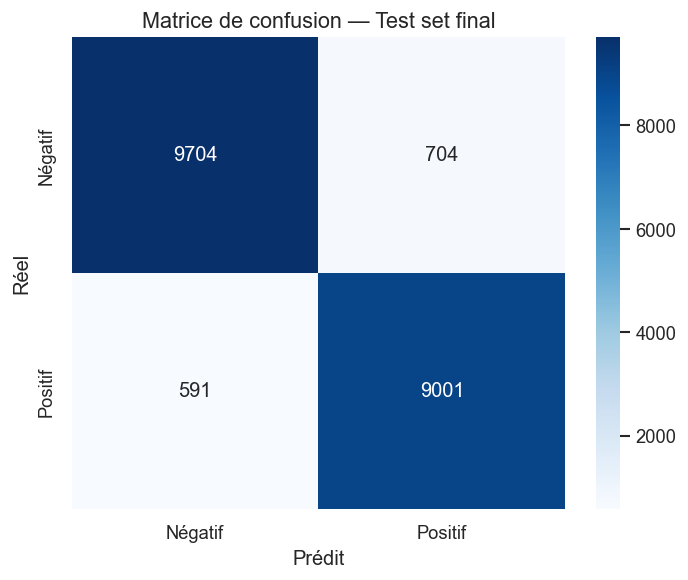

In [21]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prédictions sur le test set
y_pred_test = lr_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)

print("=" * 50)
print("   ÉVALUATION FINALE — TEST SET")
print("=" * 50)
print(f"\n📊 Accuracy : {acc_test:.4f} ({acc_test*100:.2f}%)")
print("\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred_test, target_names=["Négatif", "Positif"]))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d",
    cmap="Blues",
    xticklabels=["Négatif", "Positif"],
    yticklabels=["Négatif", "Positif"]
)
plt.title("Matrice de confusion — Test set final", fontsize=13)
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.show()